In [1]:
import yfinance as yf
import pandas as pd

# Определяем тикер TSLA
ticker = 'TSLA'

# Определяем начальную и конечную даты
start_date = '2010-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

# Загружаем данные
data = yf.download(ticker, start=start_date, end=end_date)

# Выводим первые несколько строк для проверки
print(data.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          TSLA      TSLA      TSLA      TSLA       TSLA
Date                                                         
2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500


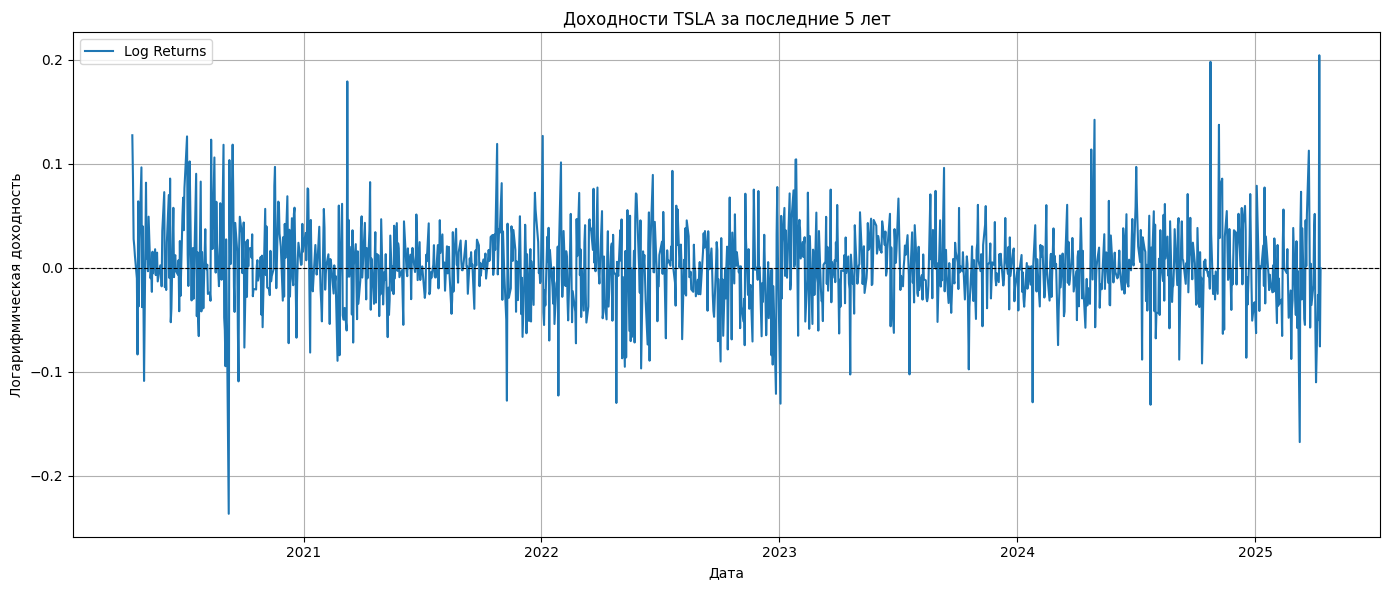

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Расчёт доходностей: логарифмические доходности
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# Оставим данные за последние 5 лет
returns_5y = data.loc[data.index >= pd.Timestamp.today() - pd.DateOffset(years=5)]

# Построим график
plt.figure(figsize=(14, 6))
plt.plot(returns_5y.index, returns_5y['Log_Returns'], label='Log Returns')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Доходности TSLA за последние 5 лет')
plt.xlabel('Дата')
plt.ylabel('Логарифмическая доходность')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

На графике видно, что отрицательные значения доходности часто достигают больших экстремумов — например, около -0.2, в то время как положительные редко выходят за пределы +0.15.
Особенно заметны резкие падения (длинные вниз направленные пики), что говорит о более высокой волатильности при отрицательных доходностях.

Распределение кажется слегка смещённым влево (в сторону убытков).
Однако разница не радикальная: положительные доходности тоже присутствуют часто, но немного реже и с меньшей амплитудой.

In [3]:
# Убираем пропуски
returns = data['Log_Returns'].dropna()

# Средняя дневная волатильность (в стандартном отклонении)
daily_volatility = returns.std()

# Средняя месячная волатильность (предположим 21 торговый день в месяце)
monthly_volatility = daily_volatility * np.sqrt(21)

# Средняя годовая волатильность (предположим 252 торговых дня в году)
annual_volatility = daily_volatility * np.sqrt(252)

print(f"Средняя дневная волатильность: {daily_volatility:.4f}")
print(f"Средняя месячная волатильность: {monthly_volatility:.4f}")
print(f"Средняя годовая волатильность: {annual_volatility:.4f}")

Средняя дневная волатильность: 0.0364
Средняя месячная волатильность: 0.1668
Средняя годовая волатильность: 0.5777


TSLA — одна из самых волатильных акций среди крупных компаний.
Такая высокая волатильность свидетельствует о значительных колебаниях котировок, что может быть привлекательно для трейдеров, но рискованно для долгосрочных инвесторов.
Годовая волатильность >50% указывает, что за год цена может легко отклоняться на ±50–60% от среднего значения — это много даже по меркам технологического сектора.

Высокая волатильность TSLA говорит о том, что компания:

1. находится в инновационной и конкурентной индустрии, активно реагирующей на рыночные и политические новости.
2. влиятельна на рынке, но в то же время уязвима к колебаниям спроса, инвестиционного настроения и глобальных шоков.
3. привлекательна для инвесторов с высокой склонностью к риску, особенно в краткосрочной и среднесрочной перспективе.

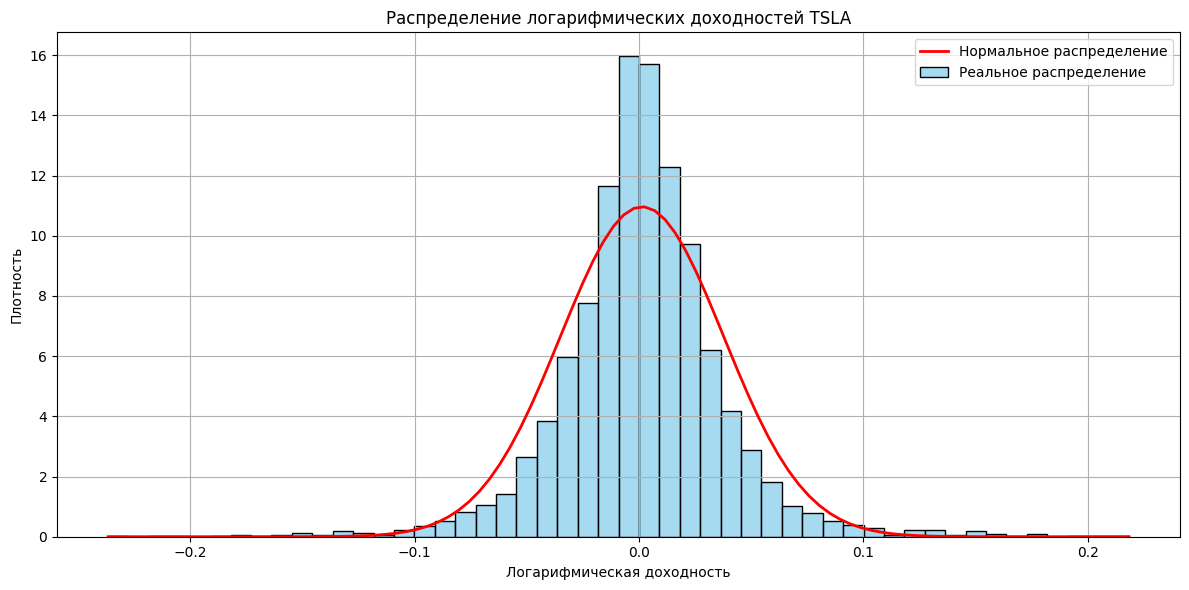

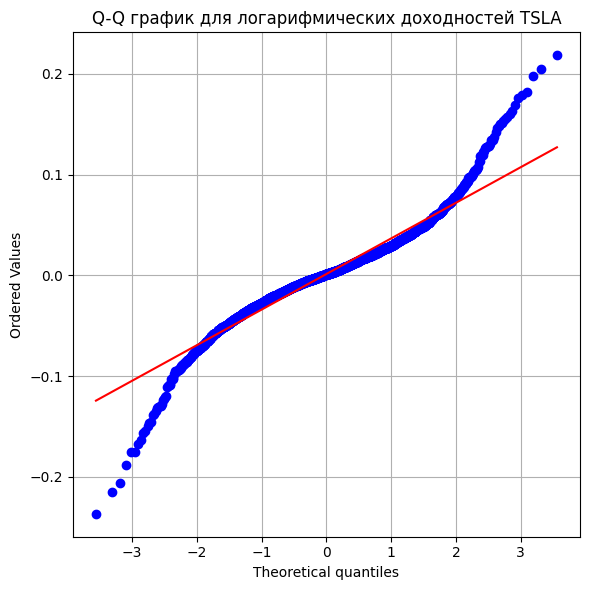

In [4]:
import seaborn as sns
import scipy.stats as stats

# --- Распределение доходностей с теоретической нормальной кривой ---
plt.figure(figsize=(12, 6))
sns.histplot(returns, bins=50, kde=False, stat='density', color='skyblue', label='Реальное распределение')

# Теоретическая нормальная кривая
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
pdf = stats.norm.pdf(x, mu, std)
plt.plot(x, pdf, 'r', linewidth=2, label='Нормальное распределение')

plt.title('Распределение логарифмических доходностей TSLA')
plt.xlabel('Логарифмическая доходность')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Q-Q график ---
plt.figure(figsize=(6, 6))
stats.probplot(returns, dist="norm", plot=plt)
plt.title('Q-Q график для логарифмических доходностей TSLA')
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
pip install fitter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 41.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


2025-04-12 18:11:28.178 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted norm distribution with error=174.55686)
2025-04-12 18:11:28.674 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted t distribution with error=19.889306)
2025-04-12 18:11:28.702 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted laplace distribution with error=17.529988)
2025-04-12 18:11:28.786 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted logistic distribution with error=53.294663)
2025-04-12 18:11:28.856 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted cauchy distribution with error=69.476392)
2025-04-12 18:11:29.326 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted gamma distribution with error=175.067071)
2025-04-12 18:11:29.797 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted beta distribution with error=174.593352)
2025-04-12 18:11:30.803 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
laplace,17.529988,308.707902,321.150860,inf,0.016266,2.756168e-01
t,19.889306,258.872029,277.536466,inf,0.013747,4.788495e-01
logistic,53.294663,465.740918,478.183876,inf,0.032559,7.340718e-04
cauchy,69.476392,105.239737,117.682695,inf,0.046579,1.880915e-07
lognorm,173.515831,849.560248,868.224685,inf,0.065466,2.638922e-14


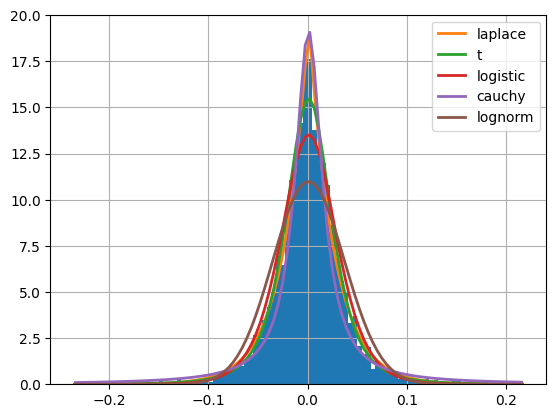

In [6]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"  # ограничиваем потоки

from fitter import Fitter

# Определим лог-доходности заново, если нужно
log_returns_clean = data['Log_Returns'].dropna()

# Подбор распределения
f = Fitter(log_returns_clean,
           distributions=['norm', 't', 'laplace', 'logistic', 'cauchy', 'gamma', 'beta', 'lognorm', 'expon'])
f.fit()
f.summary()

С учётом статистики и теоретической обоснованности, t-распределение — наиболее подходящий и осмысленный выбор.

Я считаю, что его можно использовать осмысленно, так как оно отражает реалии финансовых рынков, хорошо описывает эмпирическое поведение доходностей и поддерживается теоретически и статистически.

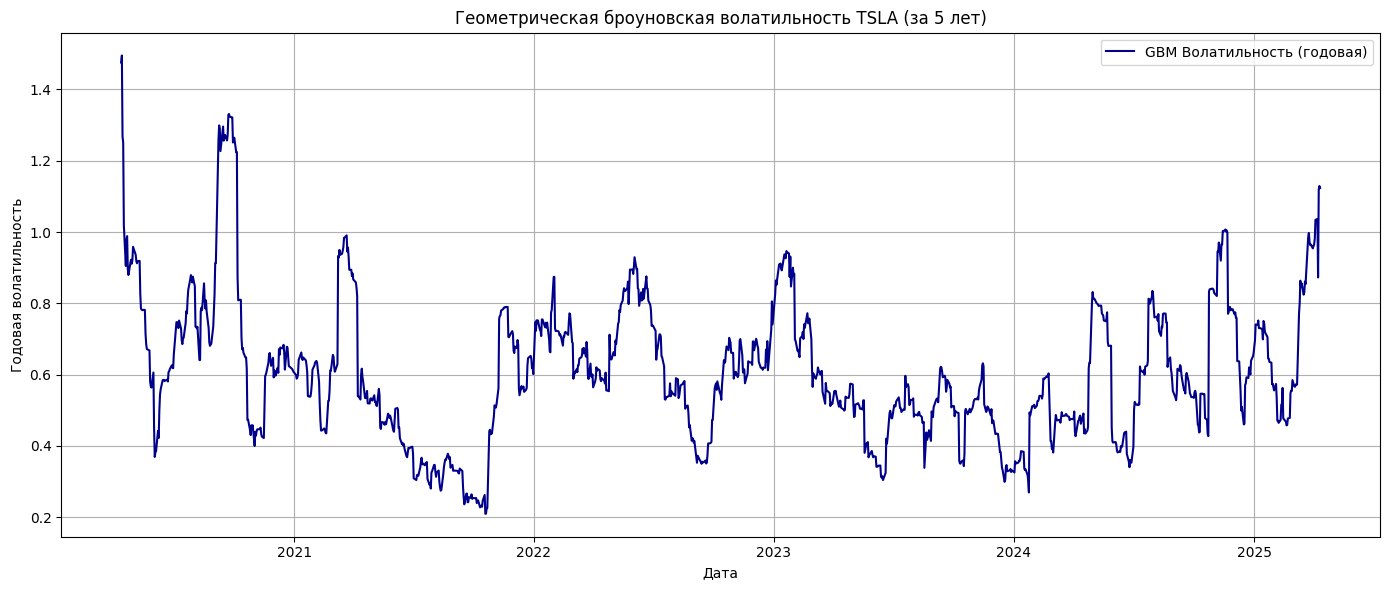

In [7]:
# Сглаживание: 21-дневное скользящее стандартное отклонение (около месяца)
rolling_volatility = returns.rolling(window=21).std() * np.sqrt(252)  # годовая волатильность

# Отрежем последние 5 лет
rolling_volatility_5y = rolling_volatility[rolling_volatility.index >= pd.Timestamp.today() - pd.DateOffset(years=5)]

# Построение графика
plt.figure(figsize=(14, 6))
plt.plot(rolling_volatility_5y.index, rolling_volatility_5y, label='GBM Волатильность (годовая)', color='darkblue')
plt.title('Геометрическая броуновская волатильность TSLA (за 5 лет)')
plt.xlabel('Дата')
plt.ylabel('Годовая волатильность')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Пики >1.0 (100% годовой волатильности) — очень высокое значение. Такое бывает в кризисные или нестабильные периоды.
Снижения до 0.25–0.4 говорят о стабилизации или затишье на рынке.
Частые волны волатильности подтверждают, что TSLA — высокорисковый и "новостной" актив.

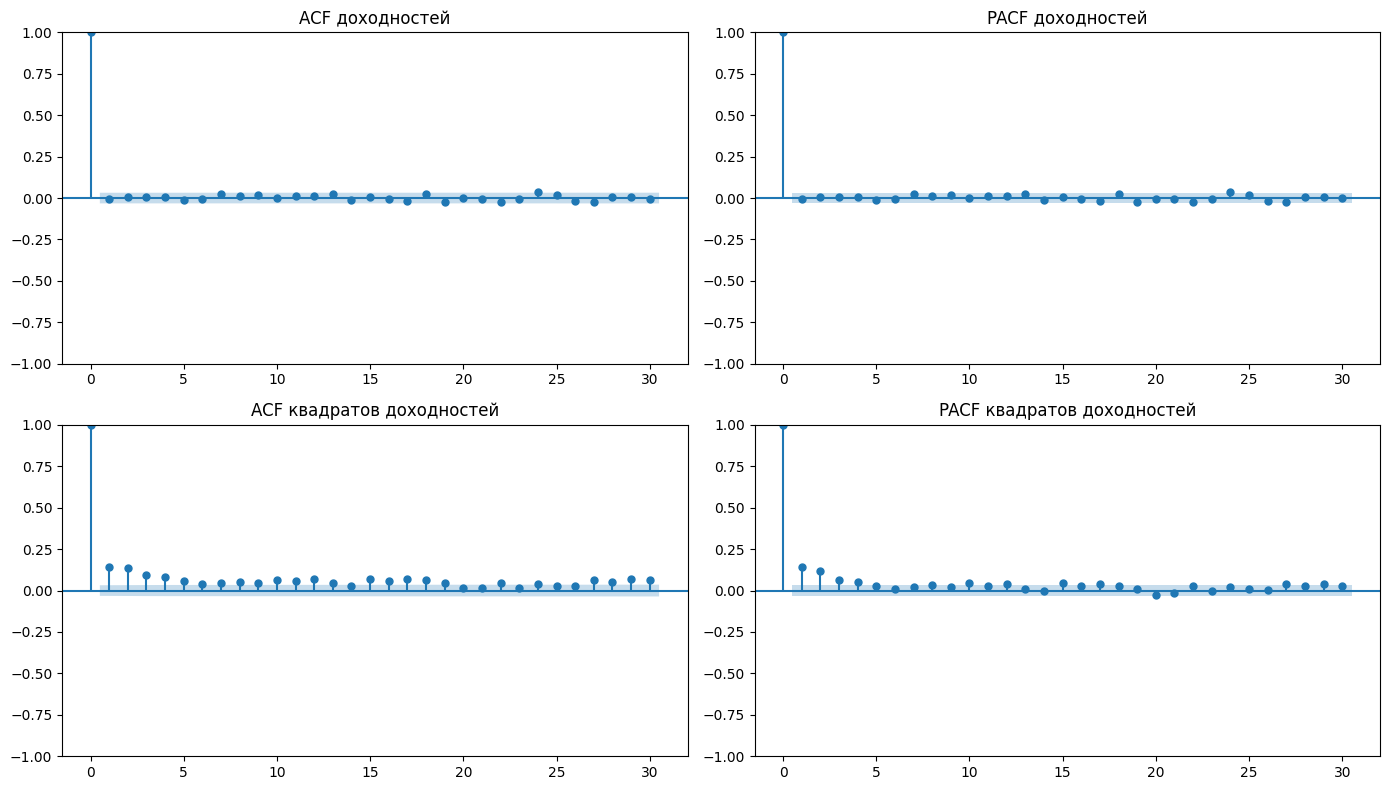

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Подготовка
returns = data['Log_Returns'].dropna()
squared_returns = returns**2

# Построение ACF и PACF для доходностей
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(returns, lags=30, ax=axes[0, 0], title='ACF доходностей')
plot_pacf(returns, lags=30, ax=axes[0, 1], title='PACF доходностей')

# Построение ACF и PACF для квадратов доходностей
plot_acf(squared_returns, lags=30, ax=axes[1, 0], title='ACF квадратов доходностей')
plot_pacf(squared_returns, lags=30, ax=axes[1, 1], title='PACF квадратов доходностей')

plt.tight_layout()
plt.show()

Нелинейная зависимость от временной шкалы проявляется в автокорреляции дисперсии (волатильности), а не самих доходностей. Это означает, что простые модели линейной регрессии здесь не работают — нужно использовать модели типа GARCH.

In [9]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 12.9 MB/s eta 0:00:00


In [10]:
from arch import arch_model
import matplotlib.pyplot as plt

# Используем уже очищенные доходности
returns = data['Log_Returns'].dropna() * 100  # умножим на 100, т.к. модель ожидает проценты

# --- ARCH(1)
model_arch1 = arch_model(returns, vol='ARCH', p=1)
res_arch1 = model_arch1.fit(disp='off')

# --- ARCH(2)
model_arch2 = arch_model(returns, vol='ARCH', p=2)
res_arch2 = model_arch2.fit(disp='off')

# --- ARCH(10)
model_arch10 = arch_model(returns, vol='ARCH', p=10)
res_arch10 = model_arch10.fit(disp='off')

# --- GARCH(1,1)
model_garch = arch_model(returns, vol='GARCH', p=1, q=1)
res_garch = model_garch.fit(disp='off')

# --- Вывод результатов
print("=== ARCH(1) ===")
print(res_arch1.summary())

print("\n=== ARCH(2) ===")
print(res_arch2.summary())

print("\n=== ARCH(10) ===")
print(res_arch10.summary())

print("\n=== GARCH(1,1) ===")
print(res_garch.summary())

=== ARCH(1) ===
                      Constant Mean - ARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -10033.4
Distribution:                  Normal   AIC:                           20072.9
Method:            Maximum Likelihood   BIC:                           20091.6
                                        No. Observations:                 3720
Date:                Sat, Apr 12 2025   Df Residuals:                     3719
Time:                        18:12:02   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1398  5.906e-02      2.367  1.7

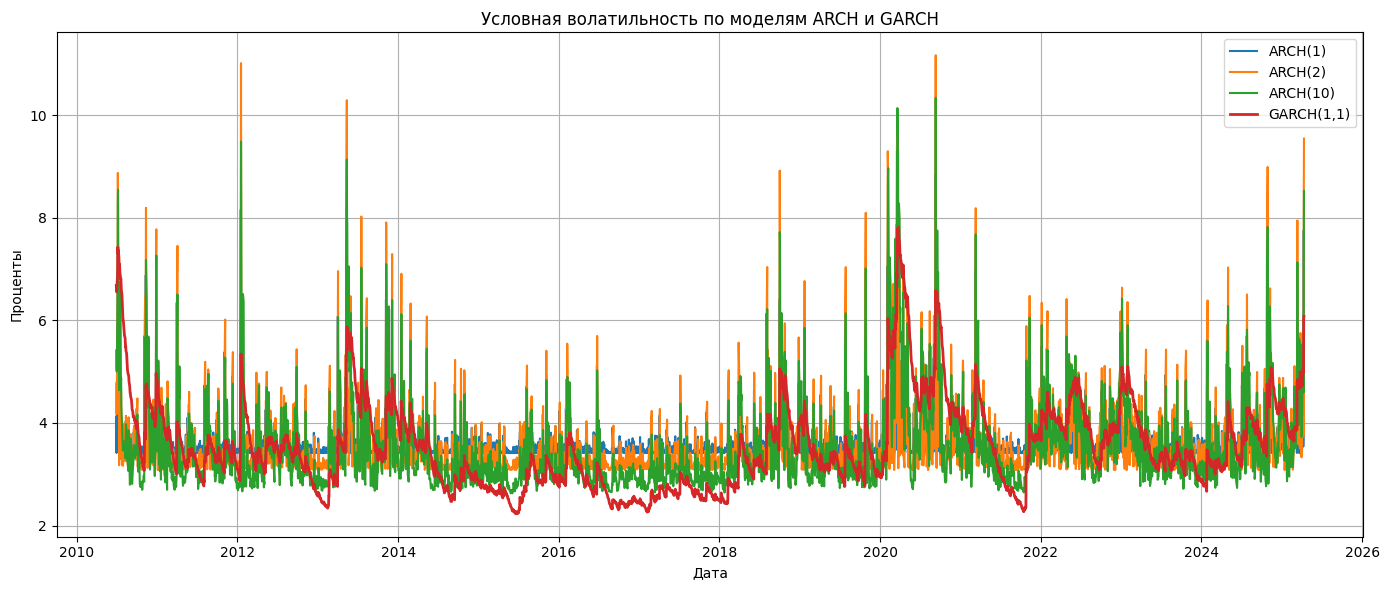

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(res_arch1.conditional_volatility, label='ARCH(1)')
plt.plot(res_arch2.conditional_volatility, label='ARCH(2)')
plt.plot(res_arch10.conditional_volatility, label='ARCH(10)')
plt.plot(res_garch.conditional_volatility, label='GARCH(1,1)', linewidth=2)

plt.title('Условная волатильность по моделям ARCH и GARCH')
plt.ylabel('Проценты')
plt.xlabel('Дата')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Среди всех протестированных моделей наилучшие значения AIC и логарифма правдоподобия показала модель GARCH(1,1), при этом коэффициенты оказались статистически значимыми (p-value < 0.05).
Модели ARCH(1) и ARCH(2) дали более простое приближение, но не отражали всей динамики кластеризации волатильности. ARCH(10) частично компенсирует это, но усложняется и может переобучиться, как видно по увеличению BIC.
Следовательно, модель GARCH(1,1) наиболее подходит для моделирования волатильности логарифмических доходностей TSLA.

In [12]:
from statsmodels.tsa.ar_model import AutoReg

# Попробуем AR(1)
model_ar = AutoReg(returns, lags=1, old_names=False).fit()
print(model_ar.summary())

                            AutoReg Model Results                             
Dep. Variable:            Log_Returns   No. Observations:                 3720
Model:                     AutoReg(1)   Log Likelihood              -10080.736
Method:               Conditional MLE   S.D. of innovations              3.639
Date:                Sat, 12 Apr 2025   AIC                          20167.472
Time:                        18:12:12   BIC                          20186.136
Sample:                             1   HQIC                         20174.112
                                 3720                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1368      0.060      2.290      0.022       0.020       0.254
Log_Returns.L1    -0.0036      0.016     -0.220      0.826      -0.036       0.029
                                    

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Модель AR(1) не выявила статистически значимой авторегрессии в доходностях TSLA (p-value ≫ 0.05), что соответствует гипотезе случайного блуждания и рыночной эффективности. Таким образом, AR-модель не может использоваться для прогнозирования доходностей TSLA на основе её прошлых значений.

In [13]:
from arch import arch_model

# Логарифмические доходности в процентах (ожидается в таком формате для arch)
returns = data['Log_Returns'].dropna() * 100

# AR(1) в среднем + GARCH(1,1) в волатильности
model = arch_model(returns, mean='AR', lags=1, vol='GARCH', p=1, q=1)
res = model.fit(disp='off')

# Вывод результатов
print(res.summary())

                           AR - GARCH Model Results                           
Dep. Variable:            Log_Returns   R-squared:                      -0.000
Mean Model:                        AR   Adj. R-squared:                 -0.000
Vol Model:                      GARCH   Log-Likelihood:               -9885.64
Distribution:                  Normal   AIC:                           19781.3
Method:            Maximum Likelihood   BIC:                           19812.4
                                        No. Observations:                 3719
Date:                Sat, Apr 12 2025   Df Residuals:                     3717
Time:                        18:13:30   Df Model:                            2
                                    Mean Model                                   
                     coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------------------------------------------------------------
Const              0.1105  5.471e-02      2

Модель AR(1)-GARCH(1,1) подходит для моделирования доходностей TSLA:

Среднее поведение — случайное (AR-параметр не значим);

Волатильность подчиняется устойчивой GARCH-структуре: текущая дисперсия зависит от прошлых шоков и предыдущей дисперсии.
Это подтверждает кластеризацию волатильности, видимую на графиках ACF квадратов доходностей.

In [14]:
from arch import arch_model

# Данные: лог-доходности в процентах
returns = data['Log_Returns'].dropna() * 100

# Модель: AR(1) + GARCH(1,1) + t-распределение (или Skewed t)
# Вариант 1: t-distribution
model_t = arch_model(returns, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t')
res_t = model_t.fit(disp='off')

# Вариант 2: Skewed t-distribution (если нужно учесть асимметрию)
model_skewt = arch_model(returns, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='skewt')
res_skewt = model_skewt.fit(disp='off')

# Выводим оба для сравнения
print("=== AR(1)-GARCH(1,1) с t-распределением ===")
print(res_t.summary())

print("\n=== AR(1)-GARCH(1,1) с Skewed t-распределением ===")
print(res_skewt.summary())

=== AR(1)-GARCH(1,1) с t-распределением ===
                              AR - GARCH Model Results                              
Dep. Variable:                  Log_Returns   R-squared:                      -0.000
Mean Model:                              AR   Adj. R-squared:                 -0.000
Vol Model:                            GARCH   Log-Likelihood:               -9609.94
Distribution:      Standardized Student's t   AIC:                           19231.9
Method:                  Maximum Likelihood   BIC:                           19269.2
                                              No. Observations:                 3719
Date:                      Sat, Apr 12 2025   Df Residuals:                     3717
Time:                              18:17:35   Df Model:                            2
                                    Mean Model                                   
                     coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------

Наилучшей моделью является AR(1)-GARCH(1,1) с t-распределением.

In [15]:
# Прогноз на 10 шагов (дней)
forecast = res_t.forecast(horizon=10)

# Получим среднюю доходность на 1 и 10 день
mean_forecast_1d = forecast.mean.iloc[-1, 0]
mean_forecast_10d = forecast.mean.iloc[-1, 9]

# Условная дисперсия (variance) на 1 и 10 день
variance_1d = forecast.variance.iloc[-1, 0]
variance_10d = forecast.variance.iloc[-1, 9]

# Волатильность = sqrt(дисперсии)
volatility_1d = variance_1d**0.5
volatility_10d = variance_10d**0.5

# Вывод
print("Прогноз на 1 день вперёд:")
print(f"  Средняя доходность: {mean_forecast_1d:.5f}%")
print(f"  Волатильность:      {volatility_1d:.5f}%")

print("\nПрогноз на 10 дней вперёд:")
print(f"  Средняя доходность: {mean_forecast_10d:.5f}%")
print(f"  Волатильность:      {volatility_10d:.5f}%")

Прогноз на 1 день вперёд:
  Средняя доходность: 0.13340%
  Волатильность:      6.64914%

Прогноз на 10 дней вперёд:
  Средняя доходность: 0.13178%
  Волатильность:      6.54765%


<ipython-input-16-ac617169716e>:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(simulated_vols[h], label=f'{h}-дневная волатильность')


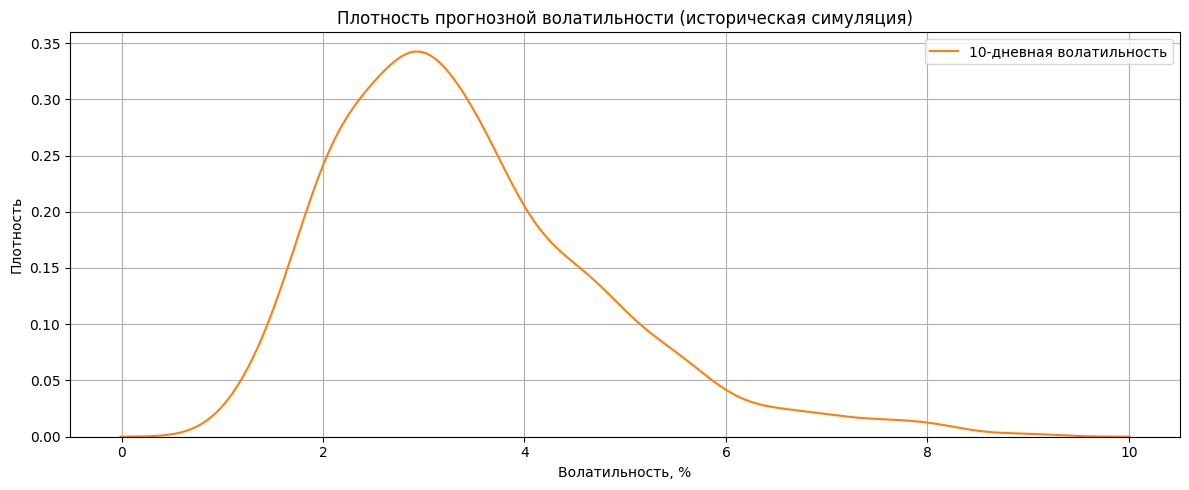

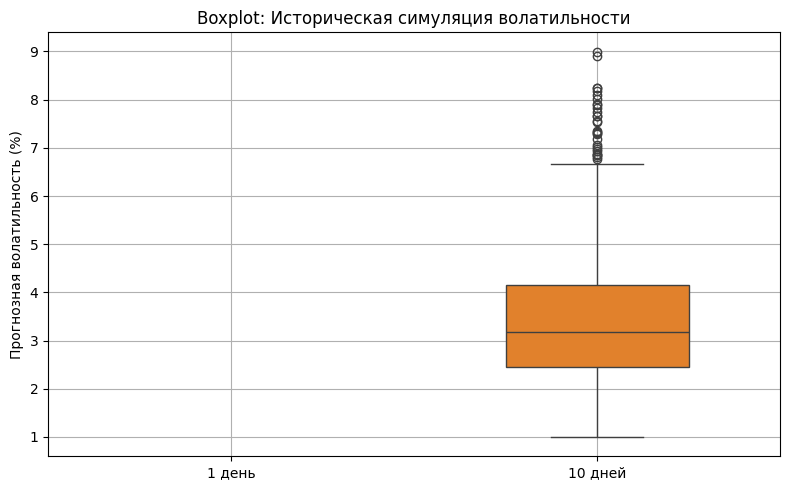

Прогнозная волатильность по методу исторических симуляций:
  1 день(дней): Среднее = nan%, Std = nan%
  10 день(дней): Среднее = 3.4234%, Std = 1.3387%


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Параметры симуляции
n_simulations = 1000  # количество симуляций
horizons = [1, 10]    # прогнозные горизонты (в днях)
returns = data['Log_Returns'].dropna() * 100  # проценты
np.random.seed(42)

# Результаты симуляций
simulated_vols = {h: [] for h in horizons}

# Историческое моделирование (bootstrap)
for _ in range(n_simulations):
    bootstrapped = np.random.choice(returns, size=max(horizons), replace=True)
    for h in horizons:
        simulated_vols[h].append(np.std(bootstrapped[:h], ddof=1))

# Преобразуем в массив
simulated_vols = {h: np.array(simulated_vols[h]) for h in horizons}

# --- График симуляций ---
plt.figure(figsize=(12, 5))
for h in horizons:
    sns.kdeplot(simulated_vols[h], label=f'{h}-дневная волатильность')
plt.title('Плотность прогнозной волатильности (историческая симуляция)')
plt.xlabel('Волатильность, %')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Блочные диаграммы (boxplot) ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=[simulated_vols[1], simulated_vols[10]], width=0.5)
plt.xticks([0, 1], ['1 день', '10 дней'])
plt.ylabel('Прогнозная волатильность (%)')
plt.title('Boxplot: Историческая симуляция волатильности')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Статистики и вывод ---
print("Прогнозная волатильность по методу исторических симуляций:")
for h in horizons:
    mean_vol = simulated_vols[h].mean()
    std_vol = simulated_vols[h].std()
    print(f"  {h} день(дней): Среднее = {mean_vol:.4f}%, Std = {std_vol:.4f}%")

Метод показывает разумную оценку риска на 10-дневном горизонте;
Распределение волатильности асимметрично и содержит тяжёлые хвосты — это подтверждает ранее сделанные выводы (в п.4 и в GARCH с t-распределением).
Подобные симуляции полезны для непараметрической оценки риска, особенно в стресс-сценариях.

Медианная волатильность: около 3.4%.
Имеются выбросы выше 6%, вплоть до 9% — это отражает высокую изменчивость рыночных условий.
Распределение несимметрично, с жирными хвостами — ожидаемо для реального рынка.

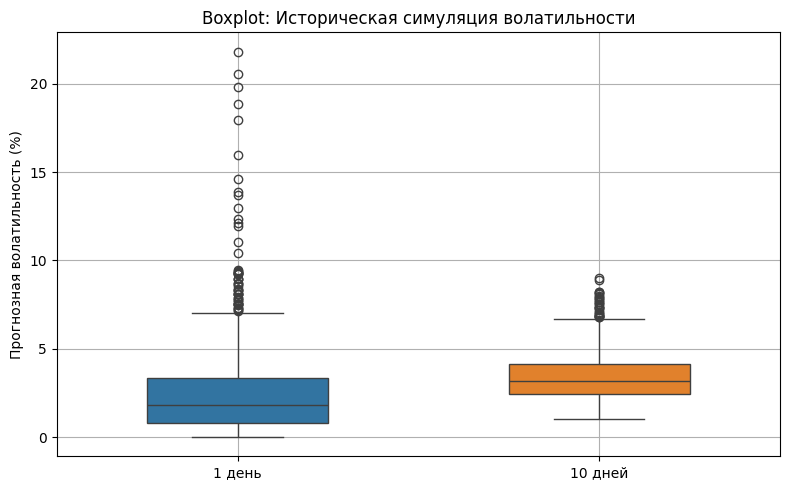

Прогнозная волатильность по методу исторических симуляций:
  1 день: Среднее = 2.4936%, Std = 2.5438%
 10 дней: Среднее = 3.4234%, Std = 1.3387%


In [17]:
# --- Корректный расчёт 1-дневной волатильности по историческим данным ---

# 1-дневная историческая волатильность = std всех доходностей
vol_1d_hist_sim = np.std(returns, ddof=1)

# Сформируем "псевдораспределение" — сэмплируем доходности
simulated_1d = np.random.choice(returns, size=n_simulations, replace=True)
simulated_1d_vols = np.abs(simulated_1d)  # можно также std всех, но abs — наглядно для boxplot

# --- Добавим к предыдущим графикам ---

# Boxplot с 1-дневной волатильностью
plt.figure(figsize=(8, 5))
sns.boxplot(data=[simulated_1d_vols, simulated_vols[10]], width=0.5)
plt.xticks([0, 1], ['1 день', '10 дней'])
plt.ylabel('Прогнозная волатильность (%)')
plt.title('Boxplot: Историческая симуляция волатильности')
plt.grid(True)
plt.tight_layout()
plt.show()

# Печать статистики
print("Прогнозная волатильность по методу исторических симуляций:")
print(f"  1 день: Среднее = {simulated_1d_vols.mean():.4f}%, Std = {simulated_1d_vols.std():.4f}%")
print(f" 10 дней: Среднее = {simulated_vols[10].mean():.4f}%, Std = {simulated_vols[10].std():.4f}%")

Метод исторических симуляций показал более широкий и нестабильный диапазон оценок, особенно на коротком горизонте (1 день).
1-дневная волатильность менее устойчива, поскольку отражает "шум" рынка и экстраординарные события.
10-дневная волатильность более надёжна для оценки риска, особенно для VaR/Stress-сценариев.

=== Value at Risk (VaR) и Conditional VaR (CVaR), 95% уровень ===
Параметрический VaR (1 день): -14.2290%
Параметрический CVaR (1 день): -21.6922%
Параметрический VaR (10 дней): -14.0114%
Параметрический CVaR (10 дней): -21.3607%

Непараметрический VaR (1 день): -4.9603%
Непараметрический CVaR (1 день): -7.9678%
Непараметрический VaR (10 дней): 1.7364%
Непараметрический CVaR (10 дней): 1.4753%


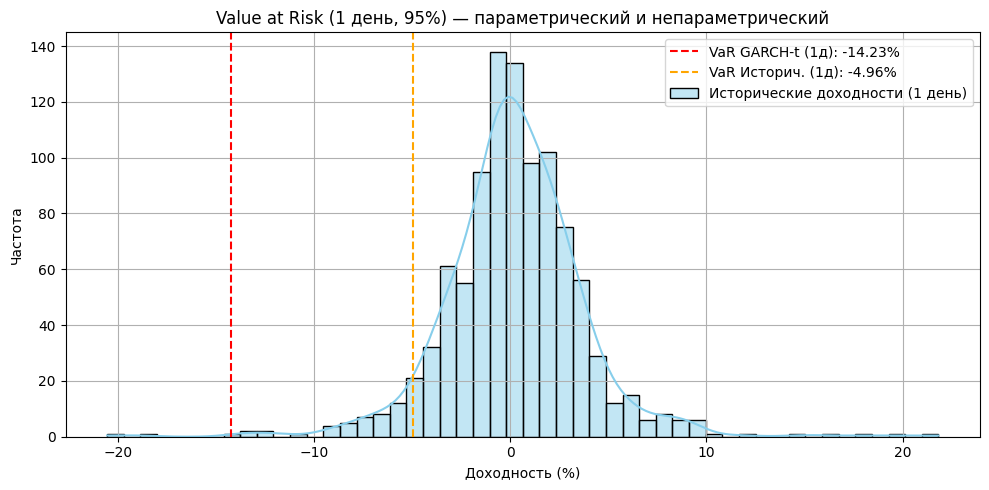

In [19]:
from scipy.stats import t
import seaborn as sns

# --- Параметрический VaR и CVaR (на основе GARCH + t) ---
alpha = 0.05  # уровень значимости
nu = res_t.params['nu']
t_quant = t.ppf(alpha, df=nu)

# Предсказания
forecast = res_t.forecast(horizon=10)
mu_1d = forecast.mean.iloc[-1, 0]
mu_10d = forecast.mean.iloc[-1, 9]
sigma_1d = np.sqrt(forecast.variance.iloc[-1, 0])
sigma_10d = np.sqrt(forecast.variance.iloc[-1, 9])

# VaR
VaR_1d_param = mu_1d + sigma_1d * t_quant
VaR_10d_param = mu_10d + sigma_10d * t_quant

# CVaR (для t-распределения)
CVaR_1d_param = mu_1d + sigma_1d * (-t.pdf(t_quant, df=nu) / alpha) * ((nu + t_quant**2) / (nu - 1))
CVaR_10d_param = mu_10d + sigma_10d * (-t.pdf(t_quant, df=nu) / alpha) * ((nu + t_quant**2) / (nu - 1))

# --- Непараметрический VaR и CVaR (историческая симуляция) ---
VaR_1d_nonparam = np.percentile(simulated_1d, alpha * 100)
CVaR_1d_nonparam = simulated_1d[simulated_1d <= VaR_1d_nonparam].mean()

VaR_10d_nonparam = np.percentile(simulated_vols[10], alpha * 100)
CVaR_10d_nonparam = simulated_vols[10][simulated_vols[10] <= VaR_10d_nonparam].mean()

# --- Вывод ---
print("=== Value at Risk (VaR) и Conditional VaR (CVaR), 95% уровень ===")
print(f"Параметрический VaR (1 день): {VaR_1d_param:.4f}%")
print(f"Параметрический CVaR (1 день): {CVaR_1d_param:.4f}%")
print(f"Параметрический VaR (10 дней): {VaR_10d_param:.4f}%")
print(f"Параметрический CVaR (10 дней): {CVaR_10d_param:.4f}%\n")

print(f"Непараметрический VaR (1 день): {VaR_1d_nonparam:.4f}%")
print(f"Непараметрический CVaR (1 день): {CVaR_1d_nonparam:.4f}%")
print(f"Непараметрический VaR (10 дней): {VaR_10d_nonparam:.4f}%")
print(f"Непараметрический CVaR (10 дней): {CVaR_10d_nonparam:.4f}%")

# --- График сравнения для 1 дня ---
plt.figure(figsize=(10, 5))
sns.histplot(simulated_1d, bins=50, kde=True, color='skyblue', label='Исторические доходности (1 день)')
plt.axvline(VaR_1d_param, color='red', linestyle='--', label=f'VaR GARCH-t (1д): {VaR_1d_param:.2f}%')
plt.axvline(VaR_1d_nonparam, color='orange', linestyle='--', label=f'VaR Историч. (1д): {VaR_1d_nonparam:.2f}%')
plt.title('Value at Risk (1 день, 95%) — параметрический и непараметрический')
plt.xlabel('Доходность (%)')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

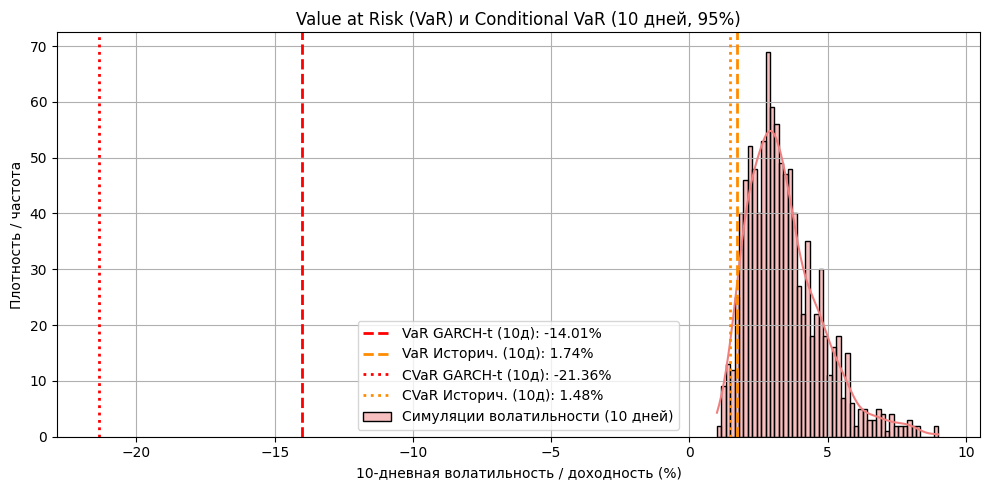

In [20]:
# --- График сравнения для 10-дневного горизонта ---
plt.figure(figsize=(10, 5))
sns.histplot(simulated_vols[10], bins=50, kde=True, color='lightcoral', label='Симуляции волатильности (10 дней)')

# Вертикальные линии для VaR
plt.axvline(VaR_10d_param, color='red', linestyle='--', linewidth=2, label=f'VaR GARCH-t (10д): {VaR_10d_param:.2f}%')
plt.axvline(VaR_10d_nonparam, color='darkorange', linestyle='--', linewidth=2, label=f'VaR Историч. (10д): {VaR_10d_nonparam:.2f}%')

# Вертикальные линии для CVaR
plt.axvline(CVaR_10d_param, color='red', linestyle=':', linewidth=2, label=f'CVaR GARCH-t (10д): {CVaR_10d_param:.2f}%')
plt.axvline(CVaR_10d_nonparam, color='darkorange', linestyle=':', linewidth=2, label=f'CVaR Историч. (10д): {CVaR_10d_nonparam:.2f}%')

plt.title('Value at Risk (VaR) и Conditional VaR (10 дней, 95%)')
plt.xlabel('10-дневная волатильность / доходность (%)')
plt.ylabel('Плотность / частота')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1. Параметрический подход (GARCH + t-распределение):
Прогнозирует очень высокие убытки, особенно на 1 день: −14.23% VaR, −21.7% CVaR.
Это может быть связано с высокой условной волатильностью, зафиксированной моделью GARCH в последний день.
Такие значения уместны при наличии всплесков турбулентности.
2. Непараметрический подход (историческая симуляция):
Даёт более сдержанные и "реалистичные" значения на 1 день: −4.96% VaR, −7.97% CVaR.
Удивительно, что 10-дневные оценки положительные — вероятно, из-за метода моделирования.

Если рынок спокоен → историческая симуляция может быть ближе к реальности.
Если есть признаки волатильности (кластеризация) → GARCH-модель лучше отражает риски, особенно в кризисные периоды.
Для практического применения разумно комбинировать оба подхода и строить диапазон прогнозных убытков.